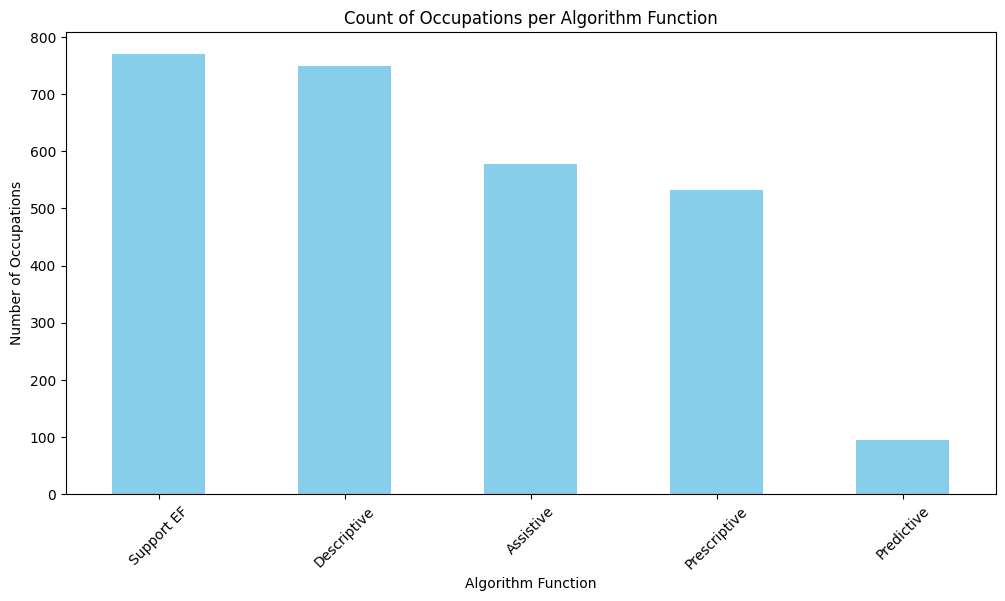

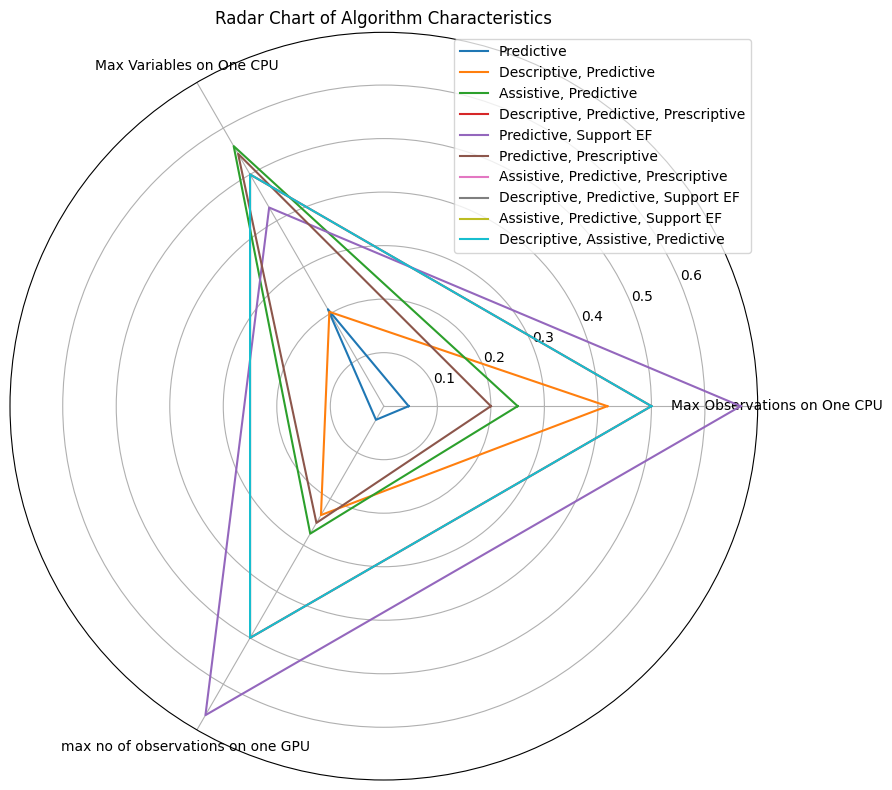

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
# Replace 'dataset.csv' with your actual file path
df = pd.read_excel('/content/sample_data/merged_data.xlsx')

# 1. Bar Chart - Count of Occupations per Algorithm Function
occupation_counts = df.groupby('Algorithm_Function')['Occupation'].nunique().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
occupation_counts.plot(kind='bar', color='skyblue')
plt.title('Count of Occupations per Algorithm Function')
plt.xlabel('Algorithm Function')
plt.ylabel('Number of Occupations')
plt.xticks(rotation=45)
plt.show()


# 2. Heatmap - Task Coverage per Algorithm Function
# task_coverage = df.groupby(['Algorithm_Function', 'Tasks']).size().unstack(fill_value=0)
# plt.figure(figsize=(14, 8))
# sns.heatmap(task_coverage, cmap='coolwarm', cbar=True)
# plt.title('Task Coverage per Algorithm Function')
# plt.xlabel('Tasks')
# plt.ylabel('Algorithm Function')
# plt.show()

# plt.figure(figsize=(12, 6))
# sns.violinplot(x='Algorithm Function_x', y='Max Observations on One CPU', data=df)
# plt.title('Distribution of CPU Observations by Algorithm')
# plt.xticks(rotation=45)
# plt.tight_layout()
# plt.show()

# plt.figure(figsize=(12, 8))
# sns.scatterplot(x='Max Observations on One CPU',
#                 y='max no of observations on one GPU ',
#                 size='Max Variables on One CPU',
#                 hue='Algorithm Function_x',
#                 data=df)
# plt.title('CPU vs GPU Observations with Variable Size')
# plt.tight_layout()
# plt.show()

import numpy as np

# Select columns for radar chart
radar_cols = ['Max Observations on One CPU',
              'Max Variables on One CPU',
              'max no of observations on one GPU ']

# Normalize the data
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

plt.figure(figsize=(10, 8))
categories = radar_cols
algorithms = df['Algorithm Function_x'].unique()

# Plot for each algorithm
for algorithm in algorithms:
    algo_data = df[df['Algorithm Function_x'] == algorithm]
    values = [normalize(algo_data[col]).mean() for col in radar_cols]
    values += values[:1]  # Repeat first value to close the polygon

    angles = [n / float(len(categories)) * 2 * np.pi for n in range(len(categories))]
    angles += angles[:1]

    plt.polar(angles, values, label=algorithm)

plt.xticks(angles[:-1], categories)
plt.title('Radar Chart of Algorithm Characteristics')
plt.legend(loc='best')
plt.tight_layout()
plt.show()

# plt.figure(figsize=(10, 8))
# categories = radar_cols
# algorithms = df['Algorithm Function_x'].unique()

# # Plot for each algorithm
# for algorithm in algorithms:
#     algo_data = df[df['Algorithm Function_x'] == algorithm]
#     values = [normalize(algo_data[col]).mean() for col in radar_cols]
#     values += values[:1]  # Repeat first value to close the polygon

#     angles = [n / float(len(categories)) * 2 * np.pi for n in range(len(categories))]
#     angles += angles[:1]

#     plt.polar(angles, values, label=algorithm)

# # Move labels farther
# plt.xticks(angles[:-1], categories, fontsize=10, rotation=0)
# for label, angle in zip(plt.gca().get_xticklabels(), angles[:-1]):
#     x, y = label.get_position()
#     label.set_position((x * 1.2, y * 1.2))  # Adjusts the distance from the center

# plt.title('Radar Chart of Algorithm Characteristics', fontsize=14)
# plt.legend(loc='best', bbox_to_anchor=(1.2, 1))
# plt.tight_layout()
# plt.show()


# 3. Scatter Plot - GPU vs CPU Observations
# plt.figure(figsize=(8, 6))
# scatter = sns.scatterplot(
#     data=df,
#     x='Max Observations on One CPU',
#     y='max no of observations on one GPU ',
#     hue='Algorithm_Function',
#     palette='viridis'
# )
# plt.title('GPU vs CPU Observations by Algorithm Function')
# plt.xlabel('Max Observations on One CPU')
# plt.ylabel('Max Observations on One GPU')
# plt.legend(title='Algorithm Function')
# plt.show()

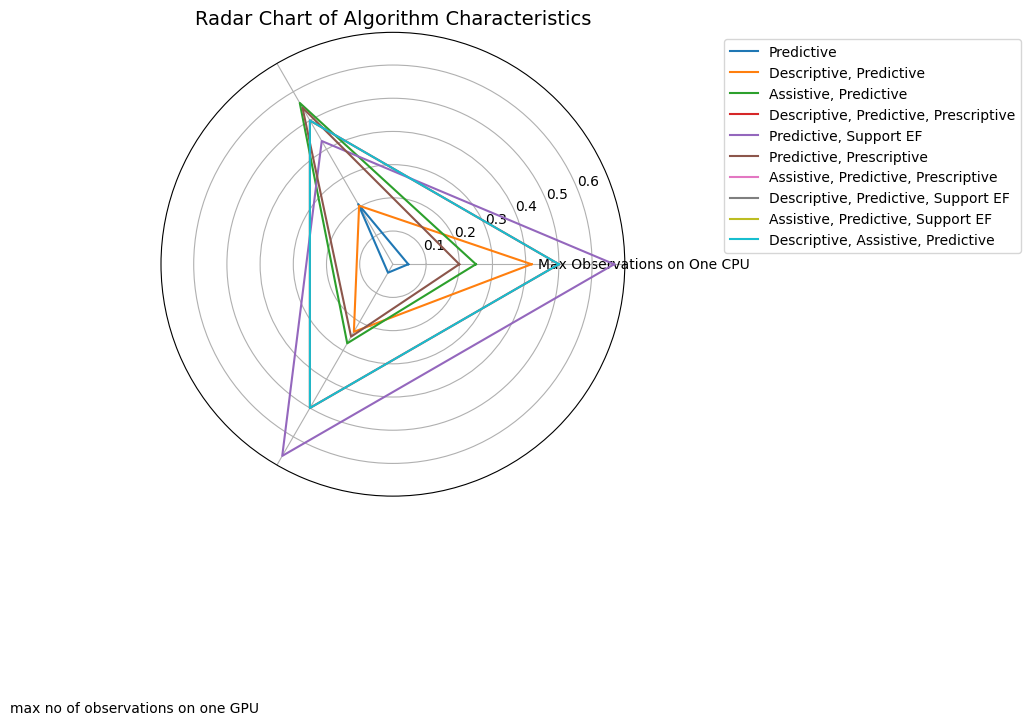

In [ ]:
import numpy as np

# Select columns for radar chart
radar_cols = ['Max Observations on One CPU',
              'Max Variables on One CPU',
              'max no of observations on one GPU ']

# Normalize the data
def normalize(series):
    return (series - series.min()) / (series.max() - series.min())

plt.figure(figsize=(10, 8))
categories = radar_cols
algorithms = df['Algorithm Function_x'].unique()

# Plot for each algorithm
for algorithm in algorithms:
    algo_data = df[df['Algorithm Function_x'] == algorithm]
    values = [normalize(algo_data[col]).mean() for col in radar_cols]
    values += values[:1]  # Repeat first value to close the polygon

    angles = [n / float(len(categories)) * 2 * np.pi for n in range(len(categories))]
    angles += angles[:1]

    plt.polar(angles, values, label=algorithm)

# Adjust labels to move them farther from the chart
angles_labels = [n / float(len(categories)) * 2 * np.pi for n in range(len(categories))]
plt.xticks(angles_labels, categories, fontsize=10)

ax = plt.gca()  # Get the current axis
for label, angle in zip(ax.get_xticklabels(), angles_labels):
    x = np.cos(angle) * 1.3  # Multiply by a factor > 1 to move outward
    y = np.sin(angle) * 1.3
    label.set_position((x, y))  # Adjust position in polar coordinates

plt.title('Radar Chart of Algorithm Characteristics', fontsize=14)
plt.legend(loc='best', bbox_to_anchor=(1.2, 1))  # Optional: Adjust legend placement
plt.tight_layout()
plt.show()
